# Adversarial example using pytorch

In this example, we redo the [adversarial example](https://gurobi-optimization-ml2gurobi.readthedocs-hosted.com/en/latest/examples/adversarial_mnist.html) of the documentation but use pytorch for training the neural network.

We don't detail the optimization model here. Please refer to the example in the documentation.

This example requires the additional packages:
 - [torch](https://pytorch.org/)
 - [torchvision](https://pytorch.org/)
 - [matplotlib](https://matplotlib.org/)
 - [skorch](https://skorch.readthedocs.io/en/stable/)

 The latter package is a wrapper for giving to pytorch a Scikit-Learn like interface.

## Import the necessary packages and load data

We import all the package we need for this example.
We fetch the MINST data set using sklearn's functionalities.

In [1]:
from matplotlib import pyplot as plt

import torch
import torchvision
from skorch import NeuralNetClassifier

import gurobipy as gp

from gurobi_ml import add_predictor_constr

In [2]:
# Get MNIST digit recognition data set
mnist_train = torchvision.datasets.MNIST(root="./MNIST", train=True, download=True)

mnist_test = torchvision.datasets.MNIST(root="./MNIST", train=False, download=True)

Flatten and scale the data

In [3]:
x_train = torch.flatten(mnist_train.data.type(torch.FloatTensor), start_dim=1)
y_train = mnist_train.targets
x_test = torch.flatten(mnist_test.data.type(torch.FloatTensor), start_dim=1)
y_test = mnist_test.targets

x_train /= 255.0  # scaling
x_test /= 255.0  # scaling

## Construct and train the neural network

We construct a sequential neural network with 2 hidden layers of 50 neurons.
To train it, we use `skorch` that provides an interface similar to `scikit-learn`.

In [14]:
nn_model = torch.nn.Sequential(
    torch.nn.Linear(28 * 28, 28),
    torch.nn.Sigmoid(),
    torch.nn.Linear(28, 28),
    torch.nn.Sigmoid(),
    torch.nn.Linear(28, 10),
    torch.nn.Softmax(1),
)

In [13]:
clf = NeuralNetClassifier(
    nn_model,
    max_epochs=50,
    lr=0.1,
    iterator_train__shuffle=True,
)

clf.fit(X=x_train, y=y_train)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x50 and 28x28)

In [6]:
print(f"Training score: {clf.score(x_train, y_train):.4}")
print(f"Validation set score: {clf.score(x_test, y_test):.4}")

Training score: 0.9893
Validation set score: 0.9722


In [7]:
nn_regression = torch.nn.Sequential(*nn_model[:-1])

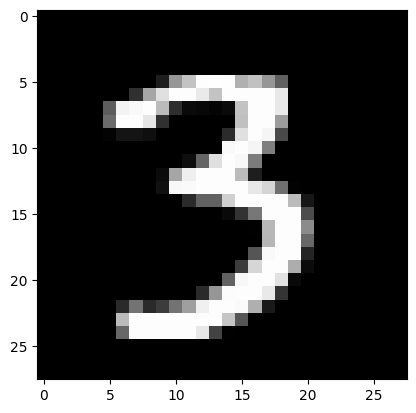

In [8]:
imageno = 10000
image = mnist_train.data[imageno, :]
plt.imshow(image, cmap="gray")

In [9]:
ex_prob = nn_regression.forward(x_train[imageno, :])
sorted_labels = torch.argsort(ex_prob)
right_label = sorted_labels[-1]
wrong_label = sorted_labels[-2]

In [10]:
image = x_train[imageno, :].numpy()  # We need numpy converted image

m = gp.Model()
delta = 5

x = m.addMVar(image.shape, lb=0.0, ub=1.0, name="x")
y = m.addMVar(ex_prob.detach().numpy().shape, lb=-gp.GRB.INFINITY, name="y")

abs_diff = m.addMVar(image.shape, lb=0, ub=1, name="abs_diff")

m.setObjective(y[wrong_label] - y[right_label], gp.GRB.MAXIMIZE)

# Bound on the distance to example in norm-1
m.addConstr(abs_diff >= x - image)
m.addConstr(abs_diff >= -x + image)
m.addConstr(abs_diff.sum() <= delta)

pred_constr = add_predictor_constr(m, nn_regression, x, y, layer_decomposition=False)

pred_constr.print_stats()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2788429
Set parameter TimeLimit to value 200000
Read parameters from file gurobi.env
WLS license 2788429 - registered to Gurobi GmbH
Model for sequential:
0 variables
0 constraints
10 general constraints
Input has shape (1, 784)
Output has shape (1, 10)

--------------------------------------------------------------------------------
Layer           Output Shape    Variables              Constraints              
                                                Linear    Quadratic      General
linear_0             (1, 50)            0            0            0            0

softplus_1           (1, 50)            0            0            0            0

linear_2             (1, 50)            0            0            0            0

softplus_3           (1, 50)            0            0            0            0

linear_4             (1, 10)            0            0            0           10

---------

In [11]:
m.Params.BestBdStop = 0.0
m.Params.BestObjStop = 0.0
m.optimize()

Set parameter BestBdStop to value 0
Set parameter BestObjStop to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Pop!_OS 24.04 LTS")

CPU model: Intel(R) Core(TM) i5-4460  CPU @ 3.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  200000
BestObjStop  0
BestBdStop  0

WLS license 2788429 - registered to Gurobi GmbH
Optimize a model with 1569 rows, 1578 columns and 3920 nonzeros (Max)
Model fingerprint: 0x294f1950
Model has 2 linear objective coefficients
Model has 10 general nonlinear constraints (51000 nonlinear terms)
Variable types: 1578 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-03, 5e+00]
  NLCon coe range  [9e-07, 1e+00]

Presolve removed 621 rows and 0 columns (presolve time = 15s)...
Added 400 variables to disaggregate expr

In [ ]:
if m.ObjVal > 0.0:
    plt.imshow(x.X.reshape((28, 28)), cmap="gray")
    x_input = torch.tensor(x.X.reshape(1, -1), dtype=torch.float32)
    label = torch.argmax(nn_model.forward(x_input))
    print(f"Solution is classified as {label}")
else:
    print("No counter example exists in neighborhood.")

copyright © 2023-2026 Gurobi Optimization, LLC